# Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report



#2. Loan dataset

> (a) Examinar el dataset Loan Data disponible en Kaggle. Indagar el diccionario de las columnas del dataset y en qué consiste el problema de predicción que puede implementarse con este dataset.

> (b) Estudiar la forma de disponer los datos directamente en memoria, usando el disco virtual de la instancia de Jupiter Lab (colab) que corre la .ipynb en la que se trabaja.

> (c) Explorar los datos, calcular el desbalance de clases y analizar los valores del  ́unico atributo no-numérico.

> (d) Implementar la función `pandas.get_dummies` de Pandas para convertir el atributo de texto en un conjunto de variables binarias.

> (e) Separar los datos en un conjunto de entrenamiento, reservando el 33 % para testing.
---

El dataset de Loan Data consiste de datos de Lending Club, una plataforma que conecta prestamistas con personas que necesitan préstamos.

Tiene información de préstamos en el período 2007-2010, y el problema de predicción es determinar si el potencial cliente va a devolver o no el préstamo.

Las columnas del dataset son:

* **credit.policy**: 1 si el cliente cumple los criterios de LendingClub.com, y 0 caso contrario.
* **purpose**: Propósito del préstamo ("credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", "all_other").
* **int.rate**: Tasa de interés del préstamo, valor entre 0 y 1. A los clientes más riesgosos se les asignan tasas de interés más altas.
* **installment**: Monto de la cuota mensual si se asigna el crédito.
* **log.annual.inc**: El logaritmo natural del ingreso anual declarado por el cliente.
* **dti**: Radio deuda/ingreso del cliente.
* **fico**: El score crediticio FICO del cliente.
* **days.with.cr.line**: La cantidad de días que el cliente lleva con una línea de crédito.
* **revol.bal**: La cantidad de dinero que el cliente deja sin pagar al cierre de la tarjeta.
* **revol.util**: La tasa de uso de la línea de crédito (usado/total disponible).
* **inq.last.6mths**: La cantidad de consultas de prestamistas sobre el cliente en los últimos 6 meses.
* **delinq.2yrs**: La cantidad de veces que el cliente se pasó más de 30 días de alguna fecha de pago en los últimos 2 años.
* **pub.rec**: La cantidad de registros públicos derogatorios del cliente (bankruptcy filings, tax liens, or judgments).

Por último, la columna objetivo es **not.fully.paid**, que indica si el cliente no devolvió la totalidad del crédito (1 si aún adeuda, 0 si pagó la totalidad).


In [2]:
# prompt: load dataset from drive, 'loan_data.csv' in the folder Docencia/CienciaDeDatos2025

# Load the dataset from Google Drive
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Docencia/CienciaDeDatos2025/loan_data.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


* Tenemos 9578 filas, sin nulos en ninguna columna.
* Hay 13 columnas numéricas y una columna no numérica.



Por comodidad, prefiero tener nombres de columnas con guiones y no con puntos, por lo cual reemplazaré los `.` por `_` en los nombres de columnas.

In [4]:
df.columns = df.columns.str.replace('.', '_')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit_policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int_rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log_annual_inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days_with_cr_line  9578 non-null   float64
 8   revol_bal          9578 non-null   int64  
 9   revol_util         9578 non-null   float64
 10  inq_last_6mths     9578 non-null   int64  
 11  delinq_2yrs        9578 non-null   int64  
 12  pub_rec            9578 non-null   int64  
 13  not_fully_paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


## Exploración de datos
Queremos estudiar cada una de las columnas del dataset, para ver el tipo de valores que tienen, y estudiar además el desbalance de clases.

Generando distribuciones categóricas...
Distribución de la variable: credit_policy


,count
credit_policy,
1,7710
0,1868


/tmp/ipykernel_23015/3030598096.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


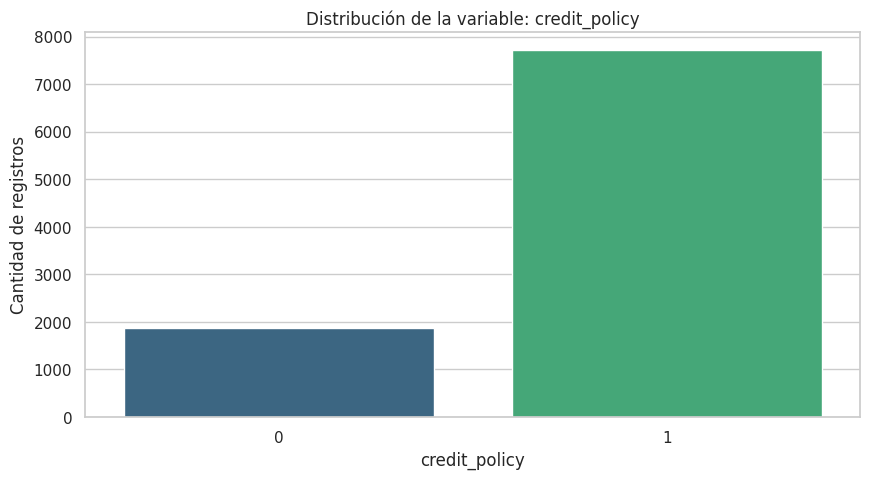

Distribución de la variable: purpose


,count
purpose,
debt_consolidation,3957
all_other,2331
credit_card,1262
home_improvement,629
small_business,619
major_purchase,437
educational,343


/tmp/ipykernel_23015/3030598096.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


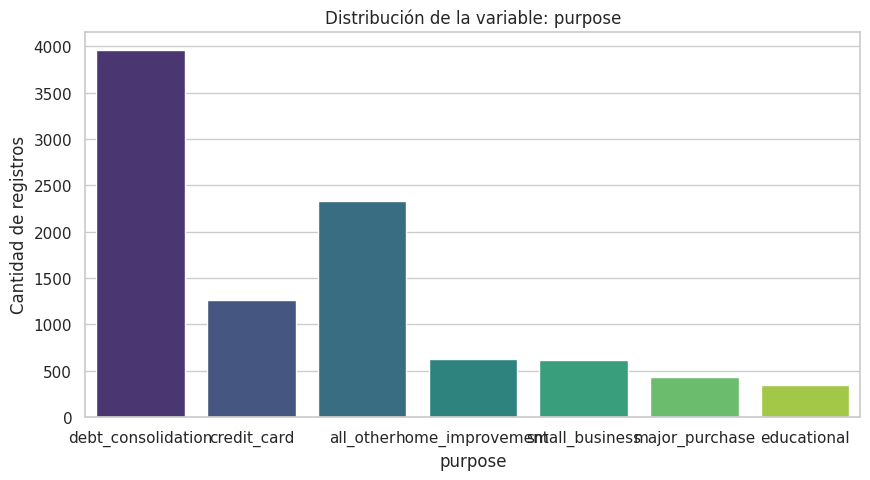



Generando distribuciones numéricas...
Distribución de la variable: int_rate


,int_rate
count,9578.000000
mean,0.122640
std,0.026847
min,0.060000
25%,0.103900
50%,0.122100
75%,0.140700
max,0.216400


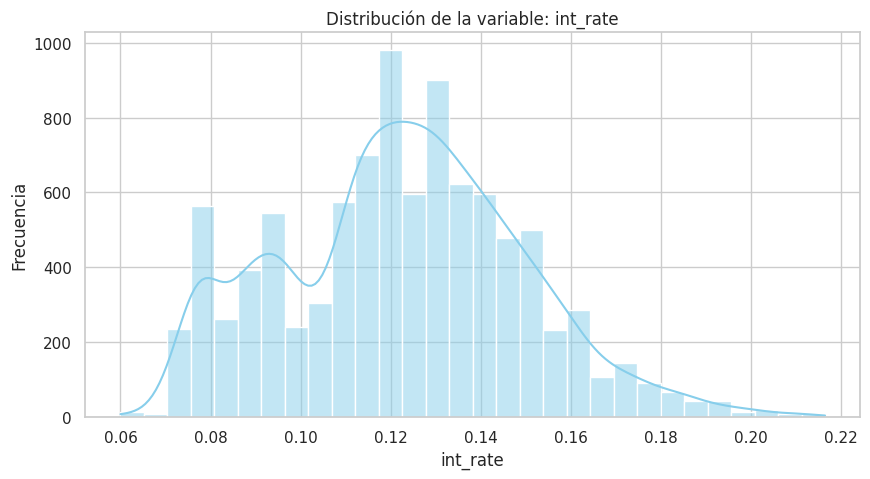

Distribución de la variable: installment


,installment
count,9578.000000
mean,319.089413
std,207.071301
min,15.670000
25%,163.770000
50%,268.950000
75%,432.762500
max,940.140000


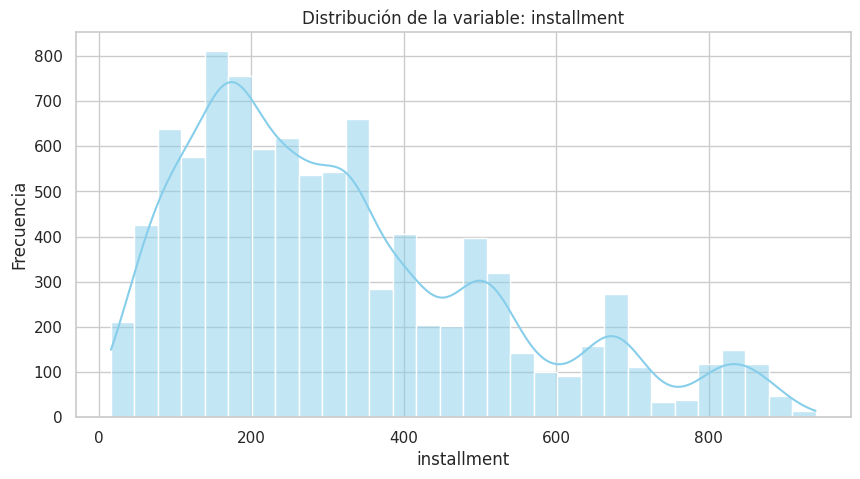

Distribución de la variable: log_annual_inc


,log_annual_inc
count,9578.000000
mean,10.932117
std,0.614813
min,7.547502
25%,10.558414
50%,10.928884
75%,11.291293
max,14.528354


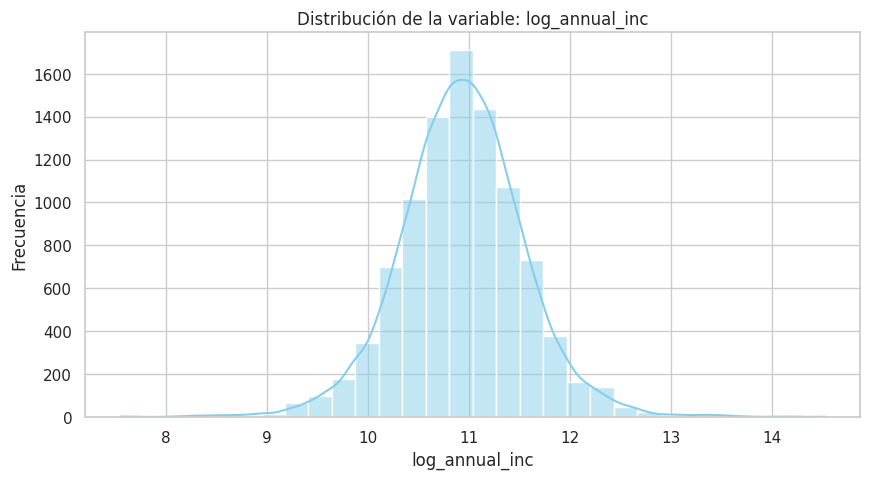

Distribución de la variable: dti


,dti
count,9578.000000
mean,12.606679
std,6.883970
min,0.000000
25%,7.212500
50%,12.665000
75%,17.950000
max,29.960000


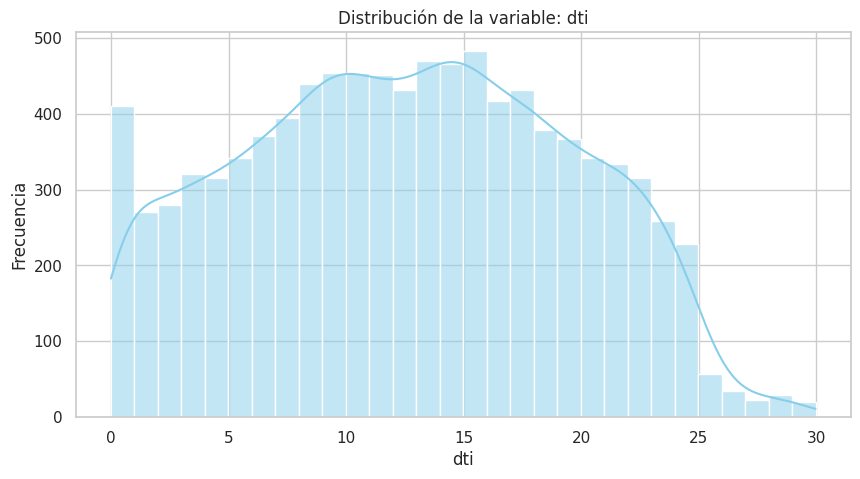

Distribución de la variable: fico


,fico
count,9578.000000
mean,710.846314
std,37.970537
min,612.000000
25%,682.000000
50%,707.000000
75%,737.000000
max,827.000000


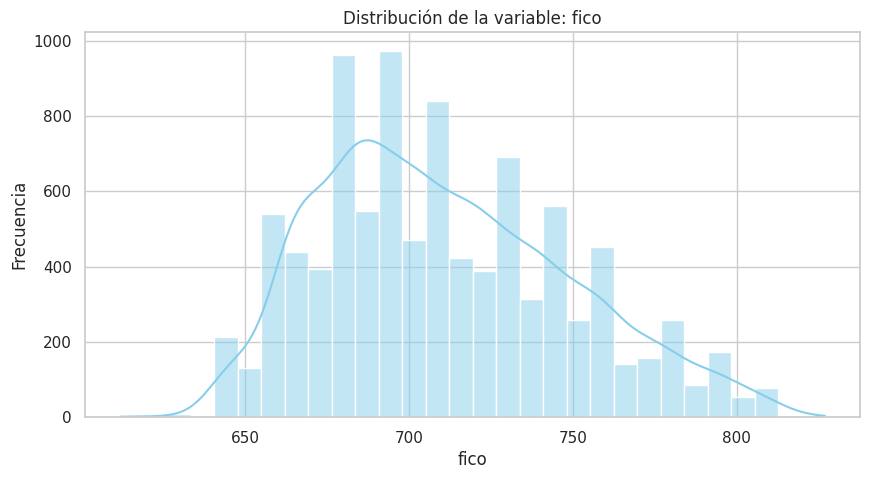

Distribución de la variable: days_with_cr_line


,days_with_cr_line
count,9578.000000
mean,4560.767197
std,2496.930377
min,178.958333
25%,2820.000000
50%,4139.958333
75%,5730.000000
max,17639.958330


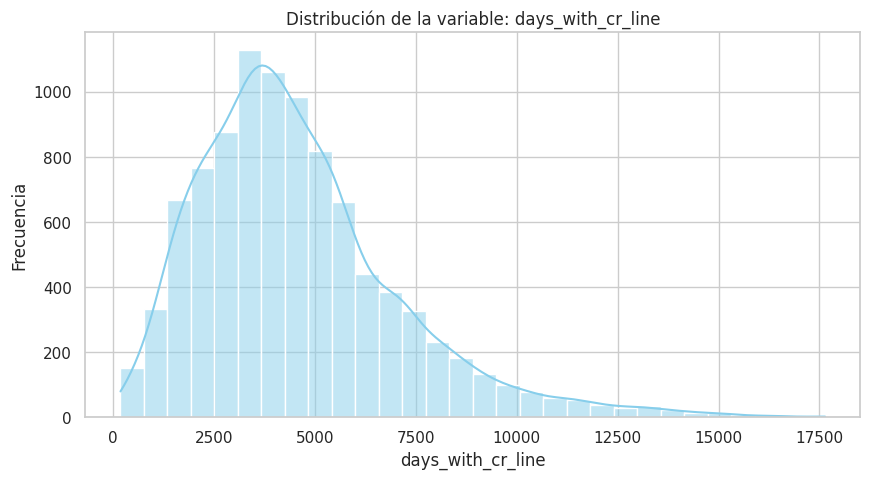

Distribución de la variable: revol_bal


,revol_bal
count,9.578000e+03
mean,1.691396e+04
std,3.375619e+04
min,0.000000e+00
25%,3.187000e+03
50%,8.596000e+03
75%,1.824950e+04
max,1.207359e+06


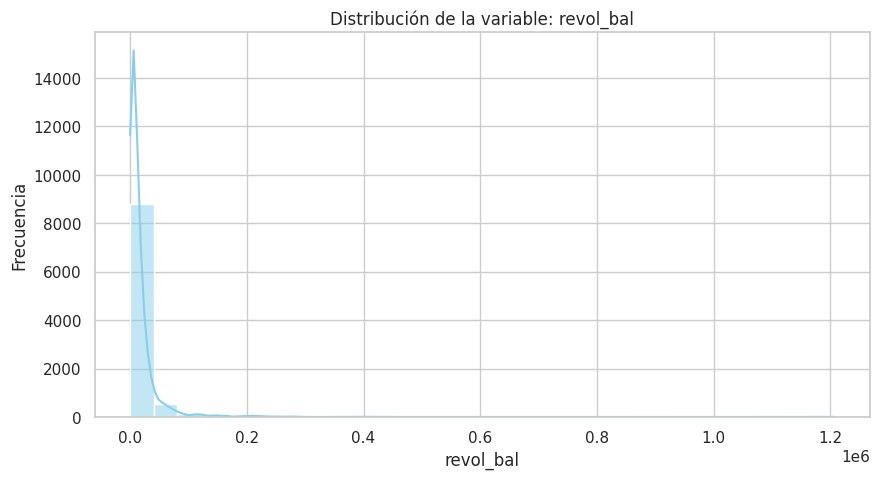

Distribución de la variable: revol_util


,revol_util
count,9578.000000
mean,46.799236
std,29.014417
min,0.000000
25%,22.600000
50%,46.300000
75%,70.900000
max,119.000000


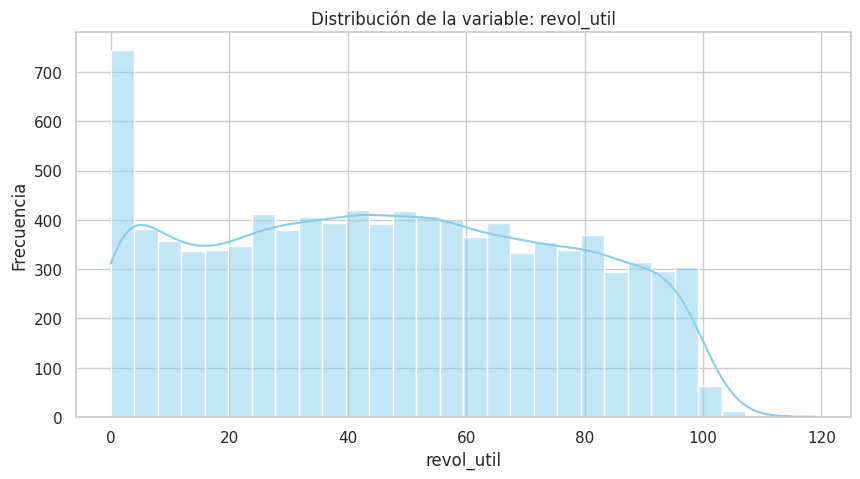

Distribución de la variable: inq_last_6mths


,inq_last_6mths
count,9578.000000
mean,1.577469
std,2.200245
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,33.000000


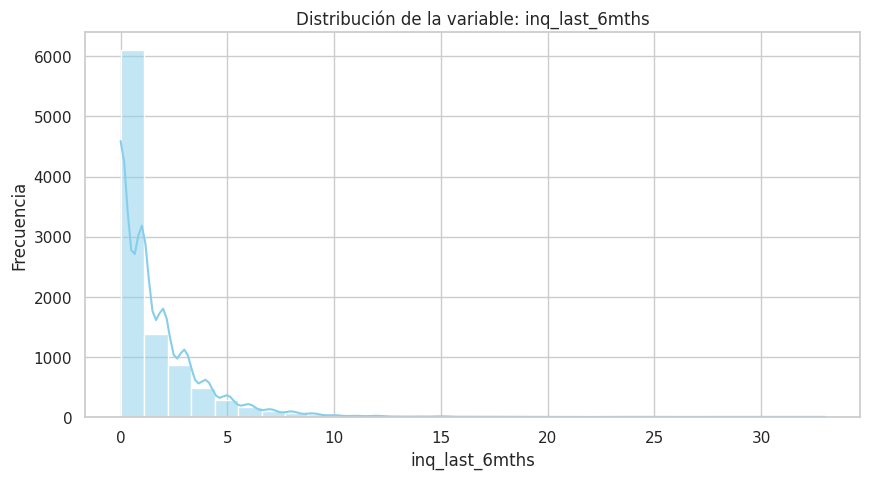

Distribución de la variable: delinq_2yrs


,delinq_2yrs
count,9578.000000
mean,0.163708
std,0.546215
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,13.000000


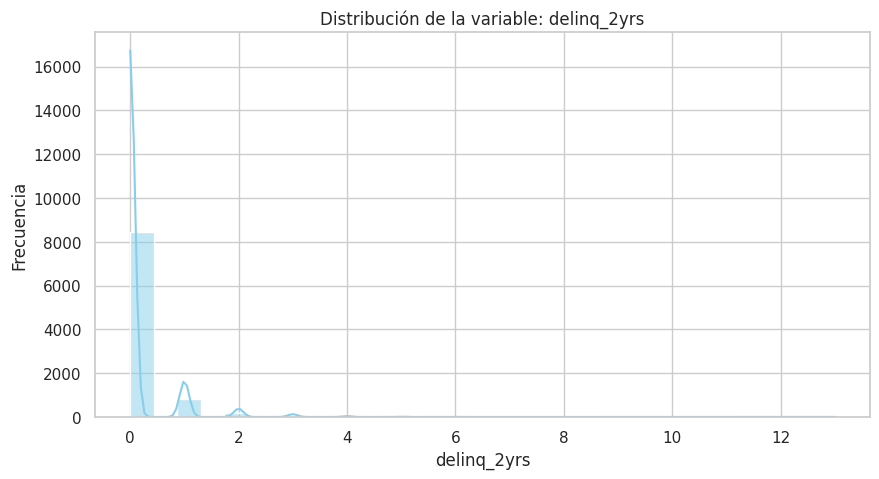

Distribución de la variable: pub_rec


,pub_rec
count,9578.000000
mean,0.062122
std,0.262126
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5.000000


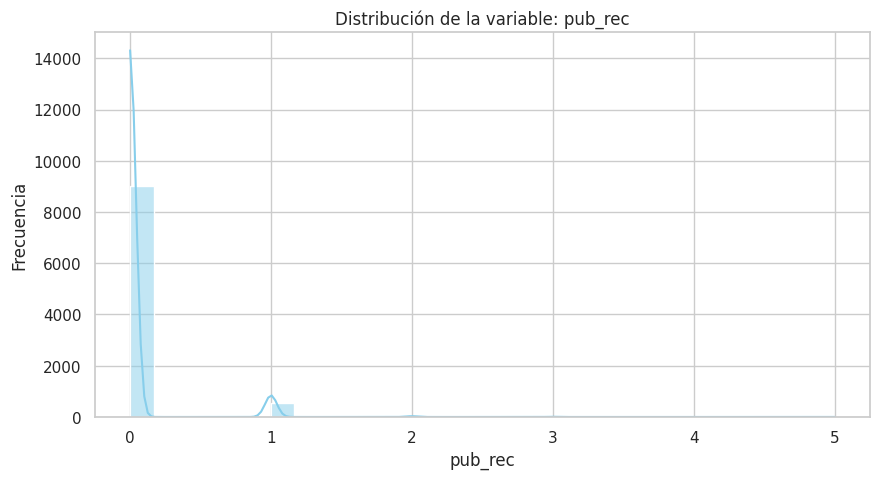

In [5]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# 1. Definir listas de columnas según su tipo
# Basado en tu descripción inicial, así quedarían tras el cambio de nombre:
cols_categoricas = ['credit_policy', 'purpose']
cols_numericas = [
    'int_rate', 'installment', 'log_annual_inc', 'dti', 'fico',
    'days_with_cr_line', 'revol_bal', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'pub_rec'
]

# 2. Visualización de Variables Categóricas (Barras de frecuencia)
print("Generando distribuciones categóricas...")
for col in cols_categoricas:
    print(f"Distribución de la variable: {col}")
    display(df[col].value_counts())
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribución de la variable: {col}')
    plt.ylabel('Cantidad de registros')
    plt.show()

# 3. Visualización de Variables Numéricas (Histogramas con KDE)
print("\n\nGenerando distribuciones numéricas...")
for col in cols_numericas:
    print(f"Distribución de la variable: {col}")
    display(df[col].describe())
    plt.figure(figsize=(10, 5))
    # El KDE (Kernel Density Estimate) ayuda a ver la forma de la curva
    sns.histplot(data=df, x=col, kde=True, color='skyblue', bins=30)
    plt.title(f'Distribución de la variable: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

### Desbalance de clases

El desbalance de clases es muy común en casi todos los problemas de clasificacion que encontramos.

Podemos mirar la cantidad de casos de cada clase, o la proporción. La proporción de casos de $\omega_i$ es un estimador de la probabilidad a priori $P(\omega_i)$.



In [6]:
display(df.not_fully_paid.value_counts())
display(df.not_fully_paid.value_counts(normalize=True))

,count
not_fully_paid,
0,8045
1,1533


,proportion
not_fully_paid,
0,0.839946
1,0.160054


## Implementación de get_dummies
La función get_dummies genera una columna booleana para cada valor único de la columna a convertir.

In [7]:
df_dummies = pd.get_dummies(df, columns=['purpose'])
df_dummies.head()

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,False,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,False,True,False,False,False,False,False


In [8]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit_policy               9578 non-null   int64  
 1   int_rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log_annual_inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days_with_cr_line           9578 non-null   float64
 7   revol_bal                   9578 non-null   int64  
 8   revol_util                  9578 non-null   float64
 9   inq_last_6mths              9578 non-null   int64  
 10  delinq_2yrs                 9578 non-null   int64  
 11  pub_rec                     9578 non-null   int64  
 12  not_fully_paid              9578 non-null   int64  
 13  purpose_all_other           9578 

Como el clasificador con el cual trabajamos es numérico, preferiríamos tener todas las columnas de tipo numérico. Podemos hacerlo cambiando el tipo de las columnas luego de aplicar `get_dummies`, pero también podríamos pedirle a `get_dummies` que use el tipo `int`.

In [9]:
df_dummies_int = pd.get_dummies(df, columns=['purpose'], dtype=int)
df_dummies_int.head()

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,0,1,0,0,0,0,0


In [10]:
df_dummies_int.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit_policy               9578 non-null   int64  
 1   int_rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log_annual_inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days_with_cr_line           9578 non-null   float64
 7   revol_bal                   9578 non-null   int64  
 8   revol_util                  9578 non-null   float64
 9   inq_last_6mths              9578 non-null   int64  
 10  delinq_2yrs                 9578 non-null   int64  
 11  pub_rec                     9578 non-null   int64  
 12  not_fully_paid              9578 non-null   int64  
 13  purpose_all_other           9578 

Podemos ver que la cantidad de 1 (o True) en cada columna dummy coincide con la cantidad de repeticiones de ese valor en la columna original.

In [11]:
df.purpose.value_counts()

,count
purpose,
debt_consolidation,3957
all_other,2331
credit_card,1262
home_improvement,629
small_business,619
major_purchase,437
educational,343


In [12]:
dummy_columns = [col for col in df_dummies_int.columns if 'purpose' in col]
df_dummies_int[dummy_columns].sum().sort_values(ascending=False)

,0
purpose_debt_consolidation,3957
purpose_all_other,2331
purpose_credit_card,1262
purpose_home_improvement,629
purpose_small_business,619
purpose_major_purchase,437
purpose_educational,343


## Separación en entrenamiento y test

**Importante:** para mejores resultados, es conveniente estratificar los split, para asegurarnos de tener ambas clases en ambos conjuntos. Esto es principalmente relevante cuando hay mucho desbalance de clases, pues podría ocurrir que si separamos al azar terminemos sin casos minoritarios en el conjunto de test.

In [13]:
df_train, df_test = train_test_split(df_dummies_int, test_size=0.33, random_state=42, stratify=df_dummies_int.not_fully_paid)

display(df_train.not_fully_paid.value_counts(normalize=True))
display(df_test.not_fully_paid.value_counts(normalize=True))

,proportion
not_fully_paid,
0,0.839956
1,0.160044


,proportion
not_fully_paid,
0,0.839924
1,0.160076


# 3. Clasificador Bayesiano


> (a) Calcular la media y la matriz de covarianza correspondiente a los datos de entrenamiento de cada una de las clases, para fijar los parámetros del clasificador bayesiano construído en el práctico anterior.

> (b) Predecir la clase de cada ejemplo del conjunto de test y evaluar la clasificación usando las funciones: accuracy score, recall score, precision score y confusion matrix de la librería sklearn.metrics y analizar los resultados.

> (c) Ignorar las correlaciones presentes entre las variables, reteniendo sólo los elementos diagonales (varianzas) en las matrices de covarianza calculadas en el item (a).

> (d) Repetir la predicción sobre el conjunto de test, usando el clasificador bayesiano sin correlaciones. Evaluar el resultado repitiendo el item (b).



---



En primer lugar, debemos separar la clase de cada muestra ($\omega$ en la teoría, aquí será $y$) de las características ($x$ en la teoría, aquí serán $X$)

In [14]:
X_train = df_train.drop('not_fully_paid', axis=1)
y_train = df_train['not_fully_paid']
X_test = df_test.drop('not_fully_paid', axis=1)
y_test = df_test['not_fully_paid']

## (a)
Ahora vamos a construir el clasificador. Al conjunto de entrenamiento lo utilizamos para conseguir la media y la varianza de las características.

Voy a definir las clases de la siguiente manera:


*   $\omega_1$: el cliente pagó su deuda totalmente. Es decir, $\omega_1$ se corresponde con $y=0$.
*   $\omega_2$: el cliente no pagó su deuda totalmente. Es decir, $\omega_2$ se corresponde con $y=1$.

$X_1$ y $X_2$ representan las variables aleatorias de características de cada clase. Si bien no sabemos que $X_1$ y $X_2$ tengan distribución normal, podemos asumir que sí por la cantidad de datos (Teorema Central del Límite).

In [15]:
mu1=X_train[y_train==0].mean().to_numpy()
mu2=X_train[y_train==1].mean().to_numpy()
sigma1=X_train[y_train==0].cov().to_numpy()
sigma2=X_train[y_train==1].cov().to_numpy()

priori2=y_train.mean()
priori1=1-priori2

print('Distribuciones a priori:')
print(f'P(y=0) = {priori1}')
print(f'P(y=1) = {priori2}')

Distribuciones a priori:
P(y=0) = 0.83995636590307
P(y=1) = 0.16004363409693004


Bajo el supuesto de que los datos siguen una **Distribución Normal Multivariada**, la función ddiscriminante para cada clase se define como:

$$g_i(x) = -\frac{1}{2}(x - \mu_i)^T \Sigma_i^{-1} (x - \mu_i) - \frac{1}{2} \ln|\Sigma_i| + \ln(P(\omega_i))$$

(En el teórico, filmina 29 de la clase 3)

El primer término se corresponde con $-\frac{1}{2}\Delta^2$, donde $\Delta$ es la distancia de Mahalanobis.

In [16]:
def dist_mahal(x,mu,sigma,cuadrado=False):
    b=x-mu
    y=np.linalg.solve(sigma,b)
    mahal2=np.dot(b,y)
    if cuadrado:
        return mahal2
    else:
        return mahal2**0.5

Escribimos el cálculo de la función discriminante.

In [17]:
def discriminant(x, media, sigma, priori):
    mahal2=dist_mahal(x,media,sigma,cuadrado=True)
    ln_det=np.log(np.linalg.det(sigma))
    ln_priori=np.log(priori)

    discriminant = -1/2*mahal2 - 1/2*ln_det + ln_priori
    return discriminant

La regla de clasificación es clasificar como $\omega_1$ si $g_1(x)>g_2(x)$, y clasificar como $\omega_2$ caso contrario.

In [18]:
def predict_class(x, mu1, mu2, sigma1, sigma2, priori1, priori2):
    g1=discriminant(x,mu1,sigma1,priori1)
    g2=discriminant(x,mu2,sigma2,priori2)
    if g1>g2:
        return 0
    else:
        return 1

def predict_sample(X, mu1, mu2, sigma1, sigma2, priori1, priori2):
    '''Recibe un dataframe X e itera sobre cada fila'''
    y_pred=[]
    for x in X.values:
        y_pred.append(predict_class(x, mu1, mu2, sigma1, sigma2, priori1, priori2))
    return np.array(y_pred)

## (b)
Ahora que tenemos el clasificador, podemos clasificar el conjunto test y analizar las métricas.

In [19]:
y_pred = predict_sample(X_test, mu1, mu2, sigma1, sigma2, priori1, priori2)


In [20]:
# Podemos ver que y_pred es un vector de ceros y unos, al igual que y_test
print(np.unique(y_pred))

[0 1]


In [21]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))

Accuracy: 0.7823473584308763
Recall: 0.26679841897233203
Precision: 0.29867256637168144


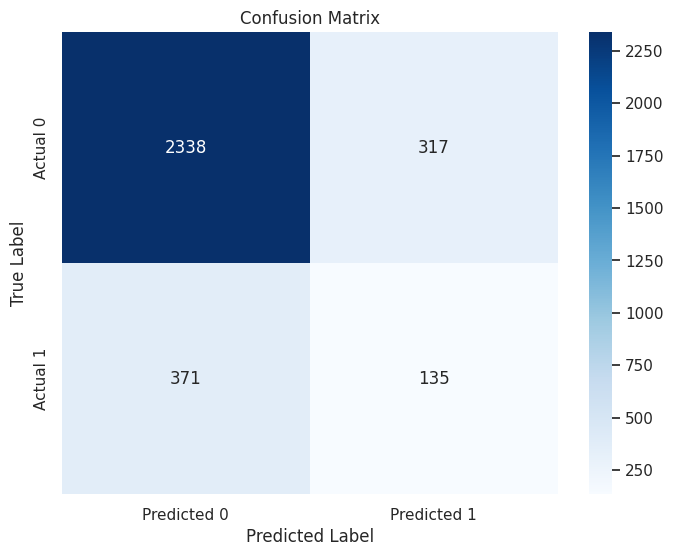

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      2655
           1       0.30      0.27      0.28       506

    accuracy                           0.78      3161
   macro avg       0.58      0.57      0.58      3161
weighted avg       0.77      0.78      0.78      3161



# Naive Bayes

Implementamos el clasificador Naive Bayes de la biblioteca sklearn.

El primer paso es hacer `fit` del clasificador sobre los datos de entrenamiento. Esto se corresponde con lo realizado en el ejercicio 3a: calculamos las medias, varianzas y probabilidades a priori utilizando los datos X_train, y_train.

In [24]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

Ahora hacemos `predict` sobre el conjunto test. Esto se corresponde con lo que realizamos en el ejercicio 3b.

In [25]:
# Usamos el clasificador gnb que ya fue ajustado a los datos de entrenamiento.
y_pred_gnb = gnb.predict(X_test)

print('Resultados sin escalar:')
print(classification_report(y_test, y_pred_gnb))

Resultados sin escalar:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      2655
           1       0.36      0.10      0.16       506

    accuracy                           0.83      3161
   macro avg       0.61      0.53      0.53      3161
weighted avg       0.77      0.83      0.78      3161



Podemos notar que el clasificador implementado con sklearn tiene peor recall y f1-score en la clase minoritaria que lo obtenido con el clasificador que implementamos manualmente. Esto se debe a funcionamientos internos de cada biblioteca, que pueden generar errores numéricos.


*   En nuestra implementación anterior, utilizamos `numpy` para realizar las cuentas, que está bien optimizado numéricamente.
*   Si bien `GaussianNB` también usa `numpy` de fondo, la implementación puede variar y permitir más errores numéricos. Para evitarlos, es conveniente que todas las variables estén en la misma escala.

En nuestro problema de clasificación tenemos características con valores muy distintos. Por ejemplo:



In [26]:
print(f'days_with_cr_line toma valores entre {df.days_with_cr_line.min()} y {df.days_with_cr_line.max()}')
print(f'int_rate toma valores entre {df.int_rate.min()} y {df.int_rate.max()}')

days_with_cr_line toma valores entre 178.9583333 y 17639.95833
int_rate toma valores entre 0.06 y 0.2164


Cuando esto ocurre, suele ser conveniente llevar los datos a la misma escala. Para ello, y considerando que suponemos que las variables son normales, podemos aplicar `StandardScaler` de sklearn, que lleva cada característica a una normal estándar.

Esta práctica la utilizaremos (por distintas razones a veces) en la mayoría de los clasificadores que utilizaremos en la materia. Al igual que con el clasificador en sí, el escalado se ajusta solo sobre los datos de entrenamiento y **luego** se aplica a los datos de test.

In [27]:
# instanciamos el escalador y lo ajustamos (con fit_transform hago el ajuste y modifico los datos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# luego uso el escalador ya ajustado para modificar el conjunto test
X_test_scaled = scaler.transform(X_test)


Ahora sí, instancio un nuevo clasificador, lo ajusto sobre los datos de entrenamiento escalados, y lo evalúo sobre los datos de test escalados.

**Importante**: Todas las transformaciones que haga sobre el conjunto de entrenamiento las debo hacer iguales sobre el conjunto de test. Si trato de evaluar el conjunto test sin escalar, o escalado con un scaler distinto, no va a dar los resultados correctos.

In [28]:
gnb_scaled = GaussianNB()

gnb_scaled.fit(X_train_scaled, y_train)
y_pred_gnb_scaled = gnb_scaled.predict(X_test_scaled)
print('Resultados con escalado:')
print(classification_report(y_test, y_pred_gnb_scaled))

Resultados con escalado:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      2655
           1       0.30      0.30      0.30       506

    accuracy                           0.77      3161
   macro avg       0.58      0.58      0.58      3161
weighted avg       0.78      0.77      0.77      3161



Con las matrices de confusion podemos visualizar fácilmente las diferencias entre ambos caminos. Podemos ver que el clasificador sobre los datos no escalados está más sesgado hacia la clase mayoritaria, llevando muchos más datos a la etiqueta $y=0$.

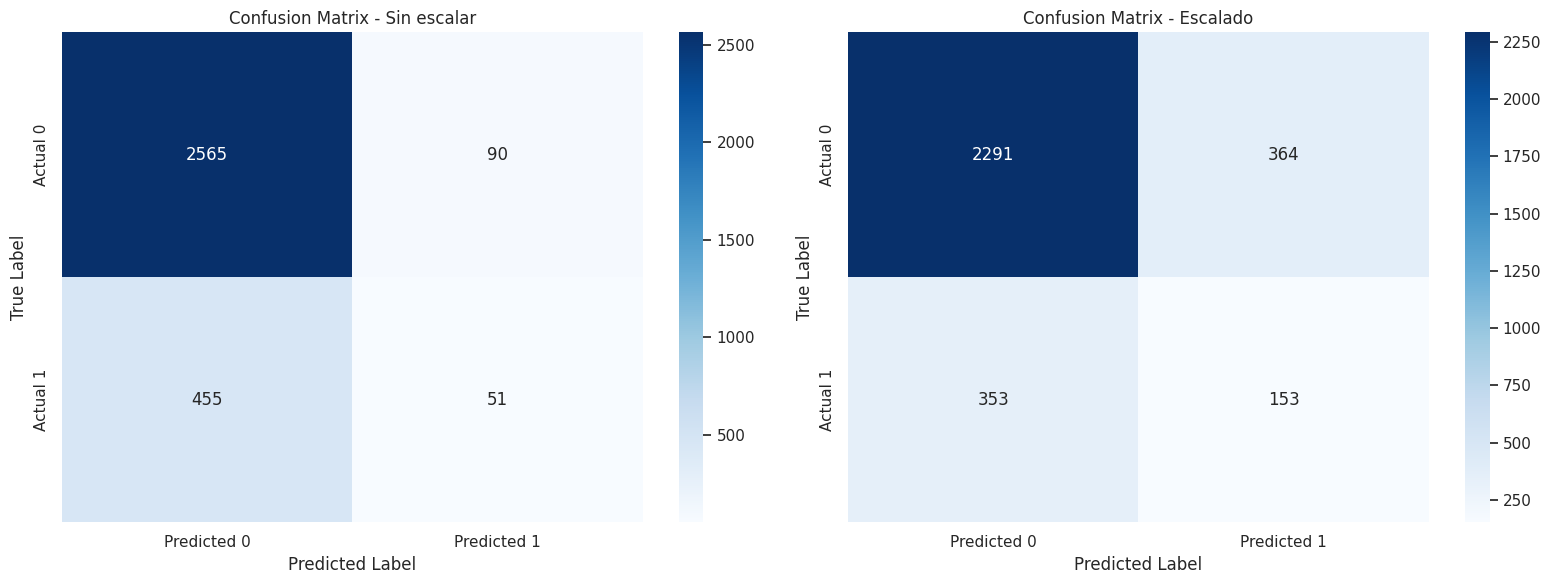

In [29]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_gnb_scaled = confusion_matrix(y_test, y_pred_gnb_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 row, 2 columns

# Plot Confusion Matrix - Sin escalar
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Sin escalar')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Confusion Matrix - Escalado
sns.heatmap(cm_gnb_scaled, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[1])
axes[1].set_title('Confusion Matrix - Escalado')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()